## 데이터 로드

In [68]:
import pandas as pd 
df = pd.read_csv("./data/ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


## 분석을 위한 2차 피쳐 선택 

In [ ]:
# 날자형# 대출 실행일 월별 변수 만들기 
df["issue_month"] = df["issue_d"].dt.month 

use_col=[
    "target",
    # 대출 기본정보 
    "loan_amnt", # 대출 금액 
    "term", # 기간
    "int_rate", #이자율 
    "sub_grade", # 등급세분류 , 
    "issue_month", # 월별 변수 파생
    "purpose", # 목적 
    "installment", #월 상환액 ($)
    "initial_list_status", # 투자자 측 펀딩 방법 
    # 차입자 정보 
    "emp_length", # 근속연수 
    "home_ownership", # 주거 형태
    "annual_inc", # 자기보고 연소득 ($)
    "addr_state", # 주 
    # 부채 관련 지표 
    "dti", # 부채대비 소득 
    "fico_mid", # 신용점 수 평균
    # 연체, 부정 이력
    "pub_rec", # 부정기록 
    "pub_rec_bankruptcies", #공공 기록상 파산 건수
    "tax_liens", # 세금 유치권(tax lien) 건수
    # 계좌 정보
    "avg_cur_bal", # 전체 계좌 평균 잔액 ($)
    "acc_open_past_24mths", # 최근 24개월간 새로 개설한 계좌 수
    "bc_open_to_buy", # 뱅크카드 잔여 한도 ($)
    "revol_bal", # 리볼빙 총 잔액 ($)
    "revol_util", # 리볼빙 이용률 (%). 사용액 / 전체 리볼빙 한도
    "num_sats", #양호 상태 계좌 수
    # 카드 정보
    "earliest_cr_line", # 차입자의 최초 신용계좌 개설일.
    "mo_sin_old_il_acct", # 가장 오래된 할부 계좌 이후 경과 월수
    "mths_since_rcnt_il",  # 가장 최근 할부 계좌 이후 경과 월수
    "mo_sin_old_rev_tl_op", #가장 오래된 리볼빙 계좌 이후 경과 월수
    "mo_sin_rcnt_rev_tl_op",  #가장 최근 리볼빙 계좌 개설 이후 경과 월수
    "mths_since_recent_inq", #가장 최근 신용 조회 이후 경과 월수
    "mths_since_recent_bc", # 가장 최근 뱅크카드 개설 이후 경과 월수
    # 이벤트 발생 여부 플래그  파생
    "mths_since_rcnt_il_flag",
    "mths_since_recent_inq_flag",
    "mths_since_recent_bc_flag",
]

df = df[use_col].copy()
print(f"전체: {len(use_col)}")
print(f"고유: {len(set(use_col))}")

전체: 33
고유: 33


In [69]:
use_col = [
    "target",
    # 대출 기본정보 
    "loan_amnt", # 대출 금액   
    "term", # 기간 
    "int_rate", #이자율 
    "sub_grade", # 등급세분류 ,   
    "installment", #월 상환액 ($)  
    "purpose", # 대출 구매 목적 
    # 차입자 정보 
    "emp_length", # 근속연수 
    "home_ownership", # 주거 형태   
    "annual_inc", # 자기보고 연소득 ($)  
    "addr_state" , # 거주 지역: 지역별 경제 상황 반영
    # 부채 관련 지표 
    "dti", # 부채대비 소득    
    "fico_mid", # 신용점 수 평균  
    # 연체, 부정 이력
    "pub_rec", # 부정기록 
    # 계좌 정보
    "avg_cur_bal", # 전체 계좌 평균 잔액 ($)  
    "bc_open_to_buy", # 뱅크카드 잔여 한도 ($)  
    "revol_bal", # 리볼빙 총 잔액 ($)  
    "revol_util", # 리볼빙 이용률 (%). 사용액 / 전체 리볼빙 한도   
    "num_rev_tl_bal_gt_0", # 부채 계좌 수 (생활 부채
    # 카드 정보
    "acc_open_past_24mths", # 최근 24개월간 새로 개설한 계좌 수
    'total_bc_limit',       # 카드 한도 (신용 체급)
    "mo_sin_old_il_acct", # 가장 오래된 할부 계좌 이후 경과 월수
    "mths_since_rcnt_il",  # 가장 최근 할부 계좌 이후 경과 월수   
    "mo_sin_old_rev_tl_op", #가장 오래된 리볼빙 계좌 이후 경과 월수   
    "mo_sin_rcnt_rev_tl_op",  #가장 최근 리볼빙 계좌 개설 이후 경과 월수
    "mths_since_recent_inq", #가장 최근 신용 조회 이후 경과 월수   
    "mths_since_recent_bc", # 가장 최근 뱅크카드 개설 이후 경과 월수   
    # 이벤트 발생 여부 플래그  파생
    "mths_since_rcnt_il_flag",  #(핵심) 
]
df = df[use_col].copy()
print(f"전체: {len(use_col)}")
print(f"고유: {len(set(use_col))}")

전체: 28
고유: 28


In [4]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                          결측수     결측률
dti                       414   0.03%
mo_sin_old_il_acct      38045   2.98%
mths_since_rcnt_il     754388  59.04%
mths_since_recent_inq  124121   9.71%
mths_since_recent_bc    12685   0.99%


## Train/ Test 분리 

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

In [6]:
#  분리
y= df["target"] # target
X = df.drop(columns=["target"]) # 설명 변수 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 컬럼 구분 

num_cols  = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"수치형: {len(num_cols)}개\n{num_cols}\n")
print(f"범주형: {len(cat_cols)}개\n{cat_cols}")

수치형: 21개
['loan_amnt', 'int_rate', 'issue_month', 'installment', 'annual_inc', 'dti', 'fico_mid', 'pub_rec', 'pub_rec_bankruptcies', 'tax_liens', 'avg_cur_bal', 'acc_open_past_24mths', 'bc_open_to_buy', 'revol_bal', 'num_sats', 'mo_sin_old_il_acct', 'mths_since_rcnt_il', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mths_since_recent_inq', 'mths_since_recent_bc']

범주형: 10개
['term', 'sub_grade', 'purpose', 'initial_list_status', 'emp_length', 'home_ownership', 'addr_state', 'mths_since_rcnt_il_flag', 'mths_since_recent_inq_flag', 'mths_since_recent_bc_flag']


## 결측지 처리 

In [7]:
# 결측 처리 
# test data로 결측 처리 수치형 
# dti 
X_train["dti"] = X_train.groupby("sub_grade")["dti"].transform(
    lambda x: x.fillna(x.median())
)

train_dit_medi = X_train.groupby("sub_grade")["dti"].median()

X_test["dti"] = X_test["dti"].fillna(X_test["sub_grade"].map(train_dit_medi))

X_train= X_train.drop(columns=["sub_grade"]) #등급 세분류 버림
X_test= X_test.drop(columns=["sub_grade"])

# 신용 조회, 
# 최대값 +1 
cols = [
'mths_since_recent_inq',
'mths_since_recent_bc', 
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1) 
    X_test[col] = X_test[col].fillna(max_val + 1) 


## mo_sin_old_il_acct  가장 오래된 할부 계좌 이후 경과 월수
## 0 으로 
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0) 
X_test["mo_sin_old_il_acct"] =  X_test["mo_sin_old_il_acct"].fillna(0) 

# mths_since_rcnt_il 가장 최근 할부 계좌(Installment Loan) 개설 이후 경과 월수
## 중앙값으로 채우기 
medi_dlq = X_train["mths_since_rcnt_il"].median()
X_train["mths_since_rcnt_il"] = X_train["mths_since_rcnt_il"].fillna(medi_dlq)
X_test["mths_since_rcnt_il"] = X_test["mths_since_rcnt_il"].fillna(medi_dlq)


In [8]:
# 확인
null_train = X_train.isnull().sum()
print(null_train[null_train>0])

null_test = X_test.isnull().sum()
print(null_test[null_test>0])

Series([], dtype: int64)
Series([], dtype: int64)


## 데이터 증강 기법 
- CTGAN 사용 

In [9]:
# 설치 
import sdv, ctgan
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata  

In [10]:
# Train 합치기 
# y_train 들어가 있어야함  
train_data = X_train.copy() 
train_data["target"] = y_train.values



In [18]:
# 모델 저장 너무오래걸림 
# 학습 후 저장
#ctgan.save("./model/ctgan_model.pkl")

# # 나중에 바로 로드해서 사용
from sdv.single_table import CTGANSynthesizer
ctgan = CTGANSynthesizer.load("./model/ctgan_model.pkl")

# # 바로 sample 가능
#synthetic_minority = ctgan.sample(num_rows=n_to_generate)

In [19]:
# train set 에 fit 

# 1. metadata 자동 감지
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(train_data)


# 2.  CTGAN 모델 설정
# ctgan = CTGANSynthesizer(
#     metadata,
#     epochs=100,                     # 훈련 반복 횟수
#     batch_size=500,                  # 배치 크기 (train 크기보다 작아야 함)
#     generator_dim=(256, 256),        # 생성자 네트워크 구조
#     discriminator_dim=(256, 256),    # 판별자 네트워크 구조
#     embedding_dim=128,               # 범주형 변수 임베딩 차원
#     generator_lr=2e-4,               # 생성자 학습률
#     discriminator_lr=2e-4,           # 판별자 학습률
#     verbose=True,                    # 훈련 과정 출력
#     cuda=True                        # GPU 사용
# )

# 핵심: Train 데이터로만 모델 훈련!
# minority만 추출 후 fit
minority_train  = train_data[train_data["target"] ==1 ]

print("CTGAN 훈련 시작... (Train 데이터만 사용)")
print(f"훈련 데이터 크기(부도 데이터만): {minority_train.shape}")
# ctgan.fit(minority_train)  # train_data만 사용!
print("훈련 완료!")

CTGAN 훈련 시작... (Train 데이터만 사용)
훈련 데이터 크기(부도 데이터만): (206618, 32)
훈련 완료!


In [20]:
# 4 합성 데이터 생성 

# 1-생성할 수량 
n_to_generate = len(train_data[train_data["target"] == 0]) - len(minority_train)
print(f" 생성할 행 수,(완납 - 부도): {n_to_generate}")

# 2- 합성 데이터 생성 
synthetic_minority = ctgan.sample(num_rows=n_to_generate)
synthetic_minority["target"] = 1  # 레이블 명시
print(f"합성 데이터 생성 완료: {synthetic_minority.shape}")
display(synthetic_minority.head())

# 3. 원본 train에 합치기
augmented_train = pd.concat([train_data, synthetic_minority], ignore_index=True)

# 4. X, y 분리
X_aug = augmented_train.drop(columns=["target"])
y_aug = augmented_train["target"]

# 5. 비율 확인
print(y_aug.value_counts(normalize=True))

 생성할 행 수,(완납 - 부도): 609003
합성 데이터 생성 완료: (609003, 32)


,loan_amnt,term,int_rate,issue_month,installment,purpose,emp_length,home_ownership,annual_inc,dti,pub_rec,initial_list_status,addr_state,earliest_cr_line,avg_cur_bal,acc_open_past_24mths,fico_mid,bc_open_to_buy,revol_bal,num_sats,pub_rec_bankruptcies,tax_liens,mo_sin_old_il_acct,mths_since_rcnt_il,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mths_since_recent_inq,mths_since_recent_bc,mths_since_rcnt_il_flag,mths_since_recent_inq_flag,mths_since_recent_bc_flag,target
0,29326.0,36 months,9.22,2,734.31,other,1 year,MORTGAGE,107588.56,15.77,0.0,w,New Jersey,1970-01-12,17592.0,4.0,682.2,167.0,30344.0,5.0,0.0,0.0,122.0,13.0,153.0,11.0,3.0,20.0,yes,yes,yes,1
1,24730.0,60 months,25.88,12,622.38,debt_consolidation,6 years,MORTGAGE,54957.05,16.52,0.0,w,Delaware,1970-01-14,4534.0,1.0,662.0,184.0,6706.0,9.0,0.0,0.0,147.0,4.0,113.0,27.0,26.0,78.0,yes,no,yes,1
2,2340.0,36 months,12.15,10,67.03,credit_card,4 years,RENT,28339.71,19.61,0.0,f,Iowa,1970-01-10,7953.0,2.0,702.0,1911.0,22115.0,4.0,0.0,0.0,131.0,12.0,263.0,18.0,20.0,20.0,no,yes,yes,1
3,7964.0,60 months,13.15,10,335.40,credit_card,8 years,OWN,159610.08,5.55,3.0,w,Nebraska,1970-01-09,25895.0,4.0,743.6,519.0,7356.0,8.0,1.0,0.0,1.0,12.0,252.0,2.0,7.0,14.0,yes,yes,yes,1
4,7689.0,36 months,15.86,12,279.26,debt_consolidation,1 year,RENT,25261.48,31.81,0.0,f,Oklahoma,1970-01-14,4392.0,6.0,694.2,379.0,4274.0,12.0,1.0,0.0,81.0,12.0,32.0,15.0,0.0,34.0,no,yes,yes,1


target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


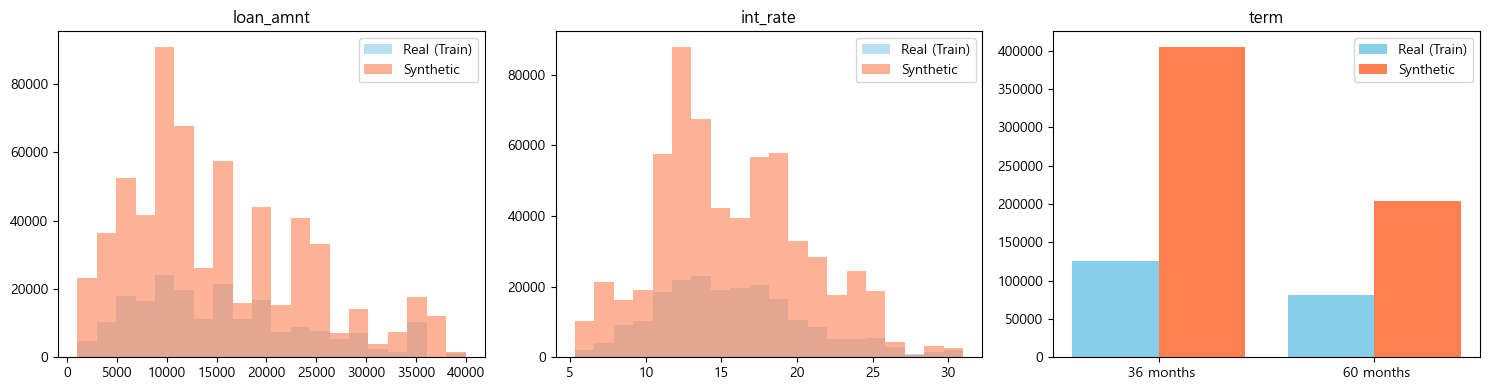

In [21]:
# 샘플 검증 비교
# 변수는 "int_rate","term", "loan_amnt" 으로만 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# loan_amnt 비교
axes[0].hist(minority_train['loan_amnt'], bins=20, alpha=0.6, label='Real (Train)', color='skyblue')
axes[0].hist(synthetic_minority['loan_amnt'], bins=20, alpha=0.6, label='Synthetic', color='coral')
axes[0].set_title('loan_amnt')
axes[0].legend()

# int_rate 비교
axes[1].hist(minority_train['int_rate'], bins=20, alpha=0.6, label='Real (Train)', color='skyblue')
axes[1].hist(synthetic_minority['int_rate'], bins=20, alpha=0.6, label='Synthetic', color='coral')
axes[1].set_title('int_rate')
axes[1].legend()

# term 비교 (범주형)
real_term = minority_train['term'].value_counts().sort_index()
syn_term = synthetic_minority['term'].value_counts().sort_index()

x = np.arange(len(real_term))
axes[2].bar(x - 0.2, real_term, 0.4, label='Real (Train)', color='skyblue')
axes[2].bar(x + 0.2, syn_term, 0.4, label='Synthetic', color='coral')
axes[2].set_xticks(x)
axes[2].set_xticklabels(real_term.index)
axes[2].set_title('term')
axes[2].legend()

plt.tight_layout()
plt.show()

In [22]:
# 샘플 품질 평가 []
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=minority_train,
    synthetic_data=synthetic_minority,
    metadata=metadata
)

quality_report.get_score()        # 전체 점수 (0~1) 
# 0.7 이상 합성 데이터로 사용 가능
quality_report.get_details("Column Shapes")       # 분포 유사도
# quality_report.get_details("Column Pair Trends")  # 변수 간 관계 유사도
# 몇몇 0.5로 성능이 낮은 것들이 있음 


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 32/32 [00:02<00:00, 12.26it/s]|
Column Shapes Score: 88.93%

(2/2) Evaluating Column Pair Trends: |██████████| 496/496 [00:15<00:00, 31.81it/s]|
Column Pair Trends Score: 87.03%

Overall Score (Average): 87.98%



,Column,Metric,Score
0,loan_amnt,KSComplement,0.899792
1,term,TVComplement,0.942890
2,int_rate,KSComplement,0.943089
3,issue_month,KSComplement,0.920318
4,purpose,TVComplement,0.833283
5,installment,KSComplement,0.965382
6,initial_list_status,TVComplement,0.930314
7,emp_length,TVComplement,0.822050
8,home_ownership,TVComplement,0.946943
9,annual_inc,KSComplement,0.910616


## 모델 생성
- Catboost 사용

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [36]:
datetime_cols = X_aug.select_dtypes(include=["datetime"]).columns.tolist()
print(datetime_cols)

# 연도만 추출 후 문자형 변환
X_aug["earliest_cr_line"] = pd.to_datetime(X_aug["earliest_cr_line"]).dt.year.astype(str)
X_test["earliest_cr_line"] = pd.to_datetime(X_test["earliest_cr_line"]).dt.year.astype(str)


[]


In [63]:
# 컬럼명 분할
num_cols = X_aug.select_dtypes(include=["number"]).columns
cat_cols = X_aug.select_dtypes(exclude=["number"]).columns

# ⚠️ cat_features 지정 방법: 인덱스 또는 컬럼명
cat_cols_list = X_aug.select_dtypes(exclude=["number"]).columns.tolist()
cat_idx = [X_aug.columns.get_loc(c) for c in cat_cols_list]

cat_cols = list(cat_cols) 

In [57]:
# 1. X_aug에서 validation 분리
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

# 2. 모델 정의
cat_model = CatBoostClassifier(
    iterations=1000, 
    learning_rate=0.05, 
    depth=8,
    l2_leaf_reg=5,
    loss_function="Logloss", 
    eval_metric="AUC", 
    random_seed=42,
    verbose=100
)

# 3. 학습 + Early Stopping
cat_model.fit(
    X_tr, y_tr,
    cat_features=cat_cols,
    eval_set=(X_val, y_val),
    early_stopping_rounds= 25  # 50 iteration 개선 없으면 중단
)

# 4. 최종 평가는 여전히 X_test로
y_pred = cat_model.predict(X_test)
proba  = cat_model.predict_proba(X_test)[:, 1]

0:	test: 0.9212996	best: 0.9212996 (0)	total: 320ms	remaining: 5m 20s
100:	test: 0.9305647	best: 0.9305647 (100)	total: 31.8s	remaining: 4m 42s
200:	test: 0.9316327	best: 0.9316327 (200)	total: 1m 4s	remaining: 4m 18s
300:	test: 0.9321101	best: 0.9321101 (300)	total: 1m 38s	remaining: 3m 49s
400:	test: 0.9323976	best: 0.9323976 (400)	total: 2m 13s	remaining: 3m 19s
500:	test: 0.9325714	best: 0.9325730 (498)	total: 2m 47s	remaining: 2m 47s
600:	test: 0.9327011	best: 0.9327011 (600)	total: 3m 22s	remaining: 2m 14s
700:	test: 0.9327897	best: 0.9327897 (700)	total: 3m 57s	remaining: 1m 41s
800:	test: 0.9328495	best: 0.9328504 (798)	total: 4m 32s	remaining: 1m 7s
900:	test: 0.9329002	best: 0.9329006 (896)	total: 5m 6s	remaining: 33.7s
Stopped by overfitting detector  (25 iterations wait)

bestTest = 0.9329041172
bestIteration = 909

Shrink model to first 910 iterations.


In [65]:
from sklearn.model_selection import GridSearchCV

# 샘플링 (2M행 → 10%만)
X_sample = X_aug.sample(frac=0.1, random_state=42)
y_sample = y_aug[X_sample.index]

param_grid = {
    "depth":         [5, 7, 10],
    "learning_rate": [0.03, 0.05, 0.1],
    "l2_leaf_reg":   [3, 5, 10],
    "iterations":    [500, 1000]
}

gs = GridSearchCV(
    CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0,
    ),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs.fit(X_sample, y_sample, cat_features=cat_cols)
print("Best params:", gs.best_params_)
print("Best AUC:", gs.best_score_)

KeyboardInterrupt: 

In [58]:
# --- 평가 ---
proba = cat_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC :", roc_auc_score(y_test, proba))

Accuracy: 0.8037055877289091
ROC-AUC : 0.7334891783375341


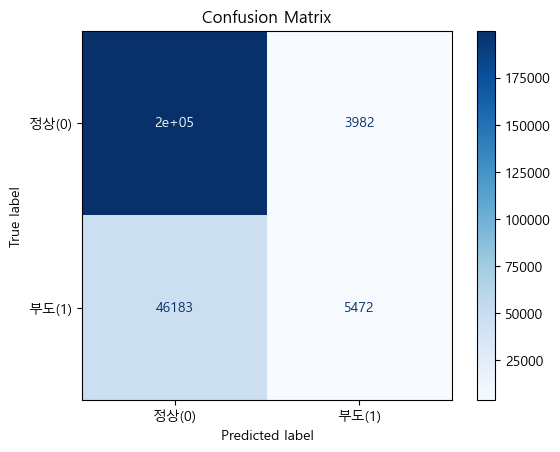

In [59]:
# 혼돈행렬 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = cat_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["정상(0)", "부도(1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [60]:
from sklearn.metrics import (
    accuracy_score, classification_report
)

y_pred = cat_model.predict(X_test)
proba  = cat_model.predict_proba(X_test)[:, 1]  # 양성(1) 확률만 담기 
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8037055877289091
              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.58      0.11      0.18     51655

    accuracy                           0.80    255560
   macro avg       0.70      0.54      0.53    255560
weighted avg       0.77      0.80      0.75    255560



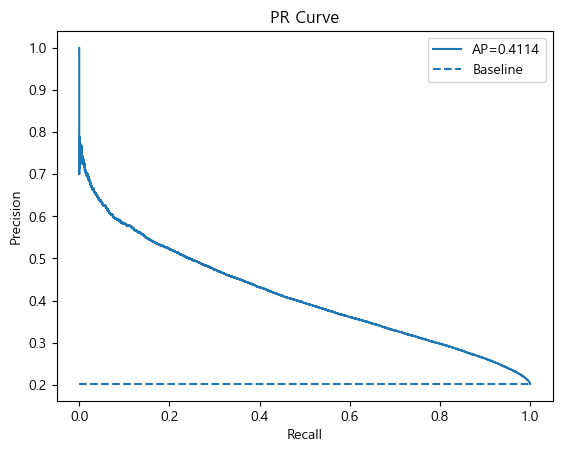

In [61]:
from sklearn.metrics import (
    precision_recall_curve, average_precision_score
)
ap = average_precision_score(y_test, proba)
prec, rec, thresholds = precision_recall_curve(y_test, proba)

plt.plot(rec, prec, label=f"AP={ap:.4f}")
plt.hlines(y_test.mean(), 0, 1, linestyles="--", label="Baseline")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("PR Curve"); plt.legend(); plt.show()

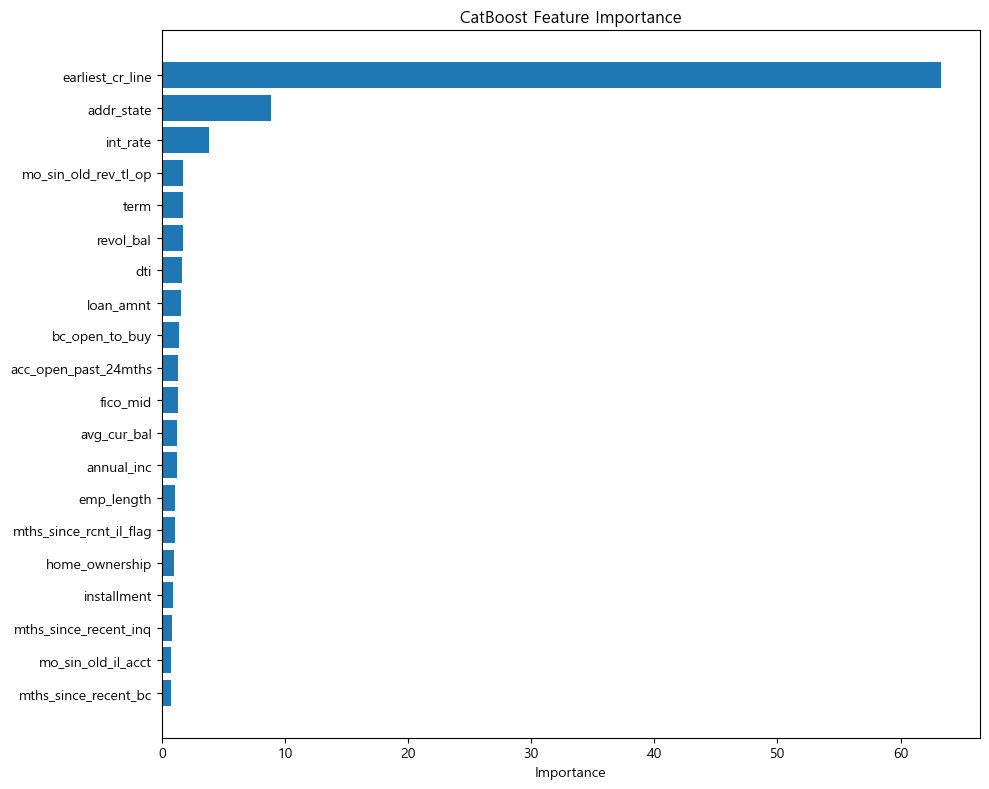

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 피처 중요도 추출
feature_importance = pd.DataFrame({
    "feature": X_aug.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

# 2. 상위 20개 시각화
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["feature"][:20][::-1],
    feature_importance["importance"][:20][::-1]
)
plt.title("CatBoost Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 모델 후 샘플 품질평가 TSTR 